In [110]:
import os
import json
import numpy as np
import torch
import cv2
from torch_geometric.data import DataLoader
from torch.utils.data import random_split
from deeplsd.models.deeplsd_inference import DeepLSD
import ground_truth.feature_extraction as ft
from ground_truth.visualization import plot_images, plot_coplanar_lines, plot_lines_bool
import matplotlib.pyplot as plt

import torch.nn as nn
import torch_geometric.nn as pyg_nn

# from models.dataset_inductive import GraphDatasetInductive
from models.model_utils import train_inductive, test_inductive, run_inference

In [ ]:
import torch 


from lightning_tools.gluestick_fully_linear import *
from lightning_tools.gluestick_CNN import *

def run_inference_lightning(
    ckpt_path: str,
    data_loader: torch.utils.data.DataLoader,
    device: torch.device = torch.device('cpu'),
    threshold_structural: float = 0.5,
    threshold_coplanarity: float = 0.5,
):
    # 1) load LightningModule (this also restores hparams)
    model = AttentionCNNCluster.load_from_checkpoint(ckpt_path)
    #print(torch.exp(-2*model.log_sigma_node),torch.exp(-2*model.log_sigma_edge))
    model = model.to(device).eval()
    # print("→ trained roi_align_embedding_shape:", model.hparams.roi_align_embedding_shape)
    # print("→ channels_conv_roi_embedding:", model.hparams.channels_conv_roi_embedding)
    # print("→ in_channels_DeepLSD:",       model.hparams.in_channels_DeepLSD)
    # print("→ expected fuse input dim:",   model.hparams.channels_conv_roi_embedding + model.hparams.in_channels_DeepLSD)
    
    all_node_probs = []
    all_edge_probs = []
    all_node_preds = []
    all_edge_preds = []

    with torch.no_grad():
        for batch in data_loader:
            batch = batch.to(device)
            # 2) forward returns raw logits
            node_logits, edge_logits = model(batch)

            # 3) turn into probs
            node_probs = torch.sigmoid(node_logits)    # shape [B, N, 1] or [N,1]


            all_node_probs.append(node_probs.cpu())
            all_edge_probs.append(edge_logits.cpu())
            # 4) threshold to get binary labels
            node_labels = (node_probs >= threshold_structural).float()

            all_node_preds.append(node_labels.cpu())
            all_edge_preds.append(edge_logits.cpu())

    return all_node_probs, all_node_preds, all_edge_probs, all_edge_preds


import os
import json
import orjson

import numpy as np
import torch
import cv2
from torch_geometric.data import Data, Dataset
# from notebooks.models.dataset_utils import extract_line_feature_ROIAlign,sample_lines_grid
from sklearn.neighbors import NearestNeighbors

from typing import Optional
import logging
    # -------------------------------------------
def line_geometry(line_pts: torch.Tensor):
    """
    line_pts : [N, 2, 2]  (x1,y1,x2,y2 per line)
    returns   :  ϕ_node   [N, 5]
    [mid_x, mid_y, dir_x, dir_y, length]
    """
    p1, p2   = line_pts[:, 0], line_pts[:, 1]           # [N,2]  [N,2]
    mid      = 0.5 * (p1 + p2)                          # [N,2]
    vec      = p2 - p1
    length   = vec.norm(dim=1, keepdim=True)            # [N,1]
    dir_norm = F.normalize(vec, dim=1)                  # [N,2]
    return torch.cat([mid, dir_norm, length], dim=1)    # [N,5]

def _load_image(filepath: str, color_conversion: Optional[int] = None) -> Optional[np.ndarray]:
    """Loads an image using OpenCV."""
    if not os.path.exists(filepath):
        logging.error(f"Image file not found: {filepath}")
        return None
    try:
        img = cv2.imread(filepath, cv2.IMREAD_UNCHANGED) # Load as is (handles color, grayscale, alpha)
        if img is None:
            logging.error(f"Failed to load image (cv2.imread returned None): {filepath}")
            return None
        if color_conversion is not None:
            img = cv2.cvtColor(img, color_conversion)
        return img
    except Exception as e:
        logging.error(f"Error loading image {filepath}: {e}")
        return None



import os
import json
import h5py
import numpy as np
import torch
import torch.nn.functional as F
import cv2
from torch.utils.data import Dataset
from torch_geometric.data import Data
from lightning_tools.line_descriptor import extract_resized_line_bands, LineSampler, EdgeSampler

def _load_image(filepath: str, color_conversion: int = None) -> np.ndarray:
    if not filepath or not os.path.exists(filepath):
        raise FileNotFoundError(f"Image file not found: {filepath}")
    img = cv2.imread(filepath, cv2.IMREAD_UNCHANGED)
    if img is None:
        raise RuntimeError(f"cv2.imread failed for: {filepath}")
    if color_conversion is not None:
        img = cv2.cvtColor(img, color_conversion)
    return img


def line_geometry(line_pts: torch.Tensor) -> torch.Tensor:
    p1, p2 = line_pts[:,0], line_pts[:,1]
    mid     = 0.5 * (p1 + p2)                       # (mx,my)

    vec = p2 - p1
    length = vec.norm(dim=1, keepdim=True)
    dir_u = F.normalize(vec, dim=1)
      # orientation
    # orientation (as column vectors)
    theta = torch.atan2(dir_u[:,1], dir_u[:,0]).unsqueeze(1)  # (N,1)
    cos2  = torch.cos(2 * theta)                             # (N,1)
    sin2  = torch.sin(2 * theta)                             # (N,1)
    return torch.cat([mid, dir_u, length, theta, cos2, sin2], dim=1)


class GraphDatasetInference(Dataset):
    def __init__(
        self,
        image_path,
        angle_field,
        distance_field,
        coords,
        roi_output_size=(64, 64),
        method="sample",
        device=None,
        edge_sample_size=(32,16)
    ):
        import os
        super().__init__()
   
        self.image_path = image_path
        self.coords = coords
        self.angle_field = angle_field
        self.distance_field = distance_field
 

        self.roi_output_size = roi_output_size
        self.method = method
        self.device = device or torch.device("cuda" if torch.cuda.is_available() else "cpu")
        num_edge, width_edge = edge_sample_size
        self.edge_sampler = EdgeSampler(num_samples_u=num_edge, num_samples_v=width_edge)
        if self.method == "sample":
            num_s, width = self.roi_output_size
            self.sampler = LineSampler(num_samples=num_s, width=width)

    def __len__(self):
        return len(self.groups)

    def __getitem__(self, idx):


        downsample_h = 1
        downsample_w = 1

        file_path_img    = self.image_path[idx]

        # build node embeddings + labels
        line_coords = self.coords[idx]
    


        # load image
        img = _load_image(file_path_img, color_conversion=cv2.COLOR_BGR2RGB)
        img_np = img

      

        coords = torch.tensor(line_coords, dtype=torch.float)
        
        
        N = coords.size(0)


      
        # extract image strips
        patches = extract_resized_line_bands(
            img=img_np,
            angle_field=self.angle_field[idx],
            distance_field=self.distance_field[idx],
            lines=coords.tolist(),
            width=20,
            target_length=20,
            downsampling_h=downsample_h,
            downsampling_w=downsample_w,
        )

        rgb_patches        = patches["rgb"]
        angle_field_patches= patches["angle_field"]
        distance_patches   = patches["distance_field"]

        
     

        # geometry and full graph
        geo = line_geometry(coords)
        # compute pairwise distances and full edge list
        p1, p2 = coords[:,0], coords[:,1]
        # seg-seg distance as in original code
        def seg_seg_dist(p1,p2,q1,q2,eps=1e-8):
            P1,P2 = p1[:,None], p2[:,None]
            Q1,Q2 = q1[None], q2[None]
            def proj(X,A,B):
                t = torch.clamp(((X-A)*(B-A)).sum(-1,keepdim=True) /
                                (((B-A)**2).sum(-1,keepdim=True)+eps), 0,1)
                return A + t*(B-A)
            d1 = ((Q1 - proj(Q1,P1,P2))**2).sum(-1)
            d2 = ((Q2 - proj(Q2,P1,P2))**2).sum(-1)
            d3 = ((P1 - proj(P1,Q1,Q2))**2).sum(-1)
            d4 = ((P2 - proj(P2,Q1,Q2))**2).sum(-1)
            return torch.sqrt(torch.min(torch.min(d1,d2), torch.min(d3,d4)))
        D = seg_seg_dist(p1,p2,p1,p2)
        # full edges
        full_idx, full_lbl = [], []
        for i in range(N):
            for j in range(N):
                full_idx.append([i,j])
        full_edge_index = torch.tensor(full_idx, dtype=torch.long).t().contiguous()
        full_edge_labels = torch.tensor(full_lbl, dtype=torch.float).unsqueeze(1)

        # k-NN local edges
        k=7
        N = D.size(1)                        # number of nodes in this graph
        k = min(k, N - 1)           # don’t ask for more than N-1 neighbors
        knn = D.topk(k+1, largest=False).indices[:,1:]
        src = torch.arange(N).unsqueeze(1).expand(-1,k).reshape(-1)
        dst = knn.reshape(-1)
        local_edge_index = torch.stack([src,dst], dim=0)

        rgb_patches = torch.from_numpy(np.array(rgb_patches))
        angle_field_patches = torch.from_numpy(np.array(angle_field_patches))
        distance_patches = torch.from_numpy(np.array(distance_patches))

        
        return Data(
            coordinates=coords,
            geo=geo,
            edge_index=local_edge_index,
            full_edge_index=full_edge_index,
            full_edge_labels=full_edge_labels,
            img=torch.tensor(img),

            rgb_patches=rgb_patches,
            angle_field_patches=angle_field_patches,
            distance_patches=distance_patches,
        )



In [112]:
# Paramaeters
image_pth          = '/mnt/c/Users/shan2/Documents/ETH/MA4/3DV/GitHub/3D-Vision/DeepLSD/notebooks/data/ai_010_008/ai_010_008/images/scene_cam_00_final_preview/frame.0045.color.jpg'
# ckpt_pth         = "lightning_tools/lightning_logs/lightning_project_both_coplanar/euvl4yo4/checkpoints/best-model-epoch=19-val_loss_epoch=0.8419.ckpt"
ckpt_pth = "lightning_tools/lightning_logs/lightning_project/z0ymr1sx/checkpoints/best-model-epoch=97-val_combined_auc_epoch=0.9686.ckpt"
ckpt_pth = "lightning_tools/lightning_logs/lightning_project/edge_sample_local_v3/checkpoints/best-model-epoch=24-val_combined_auc_epoch=0.9209.ckpt"
ckpt_pth = "lightning_tools/lightning_logs/lightning_project/attentionlinear/best-model-epoch=41-val_combined_auc_epoch=0.9618.ckpt"
ckpt_pth = "lightning_tools/lightning_logs/lightning_project/oacq0l2c/checkpoints/best-model-epoch=06-val_combined_auc_epoch=0.8490.ckpt"
ckpt_pth = "lightning_tools/lightning_logs/lightning_project/0hbfj3i1/checkpoints/best-model-epoch=12-val_combined_auc_epoch=0.8138.ckpt"

ckpt_pth = "lightning_tools/lightning_logs/lightning_project/fj87c8cq/checkpoints/best-model-epoch=03-val_combined_auc_epoch=0.8324.ckpt"
# ckpt_pth = "lightning_tools/lightning_logs/lightning_project/byfpsyz2/checkpoints/best-model-epoch=01-val_combined_auc_epoch=0.7868.ckpt"
ckpt_pth = "lightning_tools/lightning_logs/lightning_project/21pbvrmm/checkpoints/best-model-epoch=11-val_combined_auc_epoch=0.8713.ckpt"

ckpt_pth = "/mnt/c/Users/shan2/Documents/ETH/MA4/3DV/GitHub/3DV-CNN/3D-Vision/DeepLSD/notebooks/lightning_tools/lightning_logs/lightning_project/jw9qoq4a/checkpoints/cnn-epoch=10-val/ari_mean=0.2629.ckpt"
device            = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

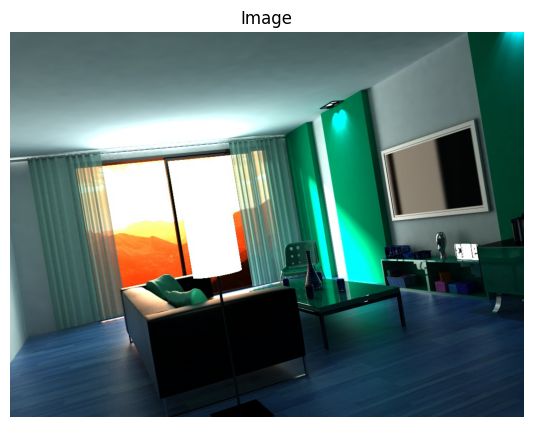

In [113]:
#color_img = cv2.imread(image_pth, cv2.IMREAD_UNCHANGED) # Load as is (handles color, grayscale, alpha)
color_img = cv2.imread(image_pth) # Load as is (handles color, grayscale, alpha)

#color_img = cv2.cvtColor(color_img, cv2.COLOR_BGR2RGB)

gray_img = cv2.cvtColor(color_img, cv2.COLOR_RGB2GRAY)

plot_images([color_img], ["Image"])

In [114]:

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
conf = {'detect_lines': True, 'line_detection_params': {'merge': False, 'filtering': True, 'grad_thresh': 3}}
ckpt = torch.load('../weights/deeplsd_md.tar', map_location=device, weights_only=False)
net = DeepLSD(conf)
net.load_state_dict(ckpt['model'])
net = net.to(device).eval()
    

In [115]:

input_tensor = torch.tensor(gray_img, dtype=torch.float32, device=device)[None, None] / 255.
with torch.no_grad():
    out = net({'image': input_tensor})
    pred_lines = out['lines'][0]
    df_norm = out['df_norm']

    angle_filed = out['line_level']

    df_np        = df_norm.squeeze(0).cpu().numpy()
    angle_np     = angle_filed.squeeze(0).cpu().numpy()
    if isinstance(pred_lines, torch.Tensor):
        pred_lines = pred_lines.cpu().numpy()
        

In [116]:
dataset = GraphDatasetInference([image_pth], [angle_np], [df_np], [pred_lines], roi_output_size=[64, 32], edge_sample_size=[32,24])





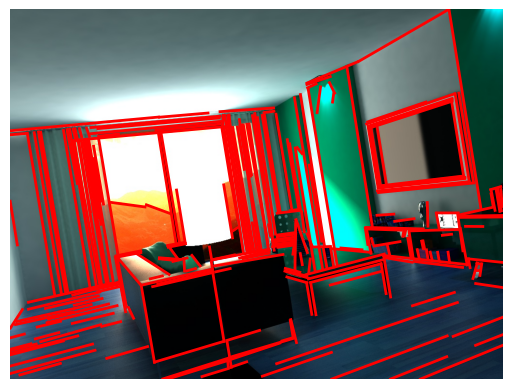

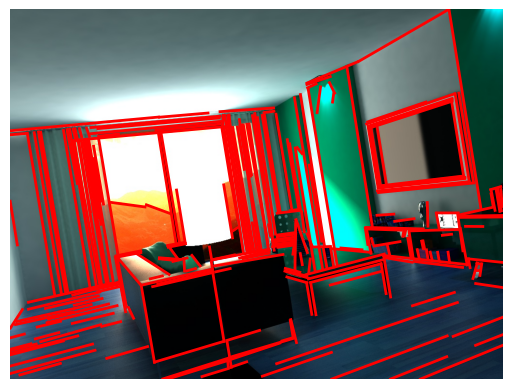

In [117]:
node_probs, node_preds, edge_probs, edge_preds = run_inference_lightning(ckpt_path=ckpt_pth, data_loader=dataset, device=device, threshold_structural=0.005, threshold_coplanarity=0.9)
fig, ax = plt.subplots()

plot_lines_bool(ax, color_img, pred_lines, node_preds[0].flatten().tolist())

import numpy as np
import matplotlib.pyplot as plt

import numpy as np
import matplotlib.pyplot as plt

def plot_lines_scores(
    ax, img, lines, scores,
    color='red',
    alpha_min=0,
    alpha_max=1.0
):
    """
    Plot lines with transparency proportional to their score.
    
    Parameters
    ----------
    ax : matplotlib Axes
    img : (H,W) or (H,W,3) image array
    lines : list of [(x0,y0), (x1,y1)] pairs
    scores : list or array of floats (any range)
    color : line color
    alpha_min : minimum alpha (for lowest score)
    alpha_max : maximum alpha (for highest score)
    """
    scores = np.asarray(scores, dtype=float)
    # normalize to [0,1]
    if scores.max() > scores.min():
        norm = (scores - scores.min()) / (scores.max() - scores.min())
    else:
        norm = np.ones_like(scores)
    # map to [alpha_min, alpha_max]
    alphas = alpha_min + norm * (alpha_max - alpha_min)

    for l, a in zip(lines, alphas):
        line = plt.Line2D(
            (l[0][0], l[1][0]),
            (l[0][1], l[1][1]),
            linewidth=2,
            color=color,
            alpha=a
        )
        ax.add_line(line)

    ax.imshow(img, cmap='gray')
    ax.set_axis_off()


fig, ax = plt.subplots()

plot_lines_scores(ax, color_img, pred_lines, node_probs[0].flatten().tolist())


import numpy as np
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score

import numpy as np
import hdbscan
from sklearn.metrics import silhouette_score

def cluster_lines_hdbscan(emb: np.ndarray,
                          min_cluster_size: int = 2,
                          min_samples: int = None,
                          scan_min_size: bool = False,
                          size_grid: int = 10,
                          verbose: bool = False):
    """
    Cluster an NxN coplanarity-distance matrix using HDBSCAN.

    Parameters
    ----------
    distance_matrix : (N, N) ndarray
        Symmetric, zero diagonal.
    min_cluster_size : int, default 2
        The minimum size of clusters; passed to HDBSCAN.
    min_samples : int | None, default None
        The number of samples in a neighborhood for a point to be considered
        a core point. If None, uses the same value as min_cluster_size.
    scan_min_size : bool, default False
        If True, will try `size_grid` different min_cluster_size values between
        `min_cluster_size` and ⌈√N⌉+1, and pick the one maximizing silhouette.
    size_grid : int, default 10
        Number of min_cluster_size values to try if scan_min_size is True.
    verbose : bool, default False
        Print silhouette scores for each tried size.

    Returns
    -------
    labels : (N,) ndarray of int
        Cluster labels (noise = -1).
    best_size : int
        The min_cluster_size that was used.
    best_silhouette : float | None
        The silhouette score (None if all points noise or only one cluster).
    """


    # helper to fit & score
    model = hdbscan.HDBSCAN(
        metric='euclidean',
        min_cluster_size=min_cluster_size,
        min_samples=min_samples,
        approx_min_span_tree=False,
        cluster_selection_epsilon=0.05,  # smaller epsilon → fewer merges

    )
    labels = model.fit_predict(emb)


    return labels




def plot_coplanar_lines(ax, lines, labels, image):
    """
    Visualize lines on an image with colors corresponding to their plane labels.
    Outliers (label -1) are drawn in grey. Designed to be used with a subplot axis.
    """
    unique_labels = sorted(set(labels))
    num_clusters = len(unique_labels)

    # Generate random colors for clusters (excluding -1 if present)
    random.seed(52)
    colors = [tuple(random.random() for _ in range(3)) for _ in range(num_clusters)]
    random.shuffle(colors)
    label_to_color = {label: colors[idx] for idx, label in enumerate(unique_labels)}

    ax.imshow(image)
    for idx, line in enumerate(lines):
        label = labels[idx]
        color = 'grey' if label == -1 or label == 0 else label_to_color.get(label, (0, 0, 0))
        
        ax.plot(
            [line[0, 0], line[1, 0]],
            [line[0, 1], line[1, 1]],
            color=color,
            linewidth=2
        )

    # ax.set_title("Coplanar Lines")
    ax.axis('off')
    
    

def plot_coplanar_lines_full(ax, lines, labels, image, idi):
    """
    Visualize lines on an image with colors corresponding to their plane labels.
    Outliers (label -1) are drawn in grey. Designed to be used with a subplot axis.
    """
    unique_labels = sorted(set(labels))
    num_clusters = len(unique_labels)

    # Generate random colors for clusters (excluding -1 if present)
    random.seed(52)
    colors = [tuple(random.random() for _ in range(3)) for _ in range(num_clusters)]
    random.shuffle(colors)
    label_to_color = {label: colors[idx] for idx, label in enumerate(unique_labels)}

    ax.imshow(image)
    for idx, line in enumerate(lines):
        label = labels[idx]
        color = 'grey' if label == -1 or label == 0 else label_to_color.get(label, (0, 0, 0))
        
        
        ax.plot(
            [line[0, 0], line[1, 0]],
            [line[0, 1], line[1, 1]],
            color='green' if idx == idi else color,
            linewidth=2
        )

    ax.set_title("Coplanar Lines")
    ax.axis('off')
    

In [118]:
labels= cluster_lines_hdbscan(edge_probs[0].numpy(), min_cluster_size=6
                              
                              , min_samples=3, size_grid=5000)

# labels = cluster_coplanar_lines_symmetric(M=edge_probs_array, prob_threshold=0.3, min_cluster_size=2)

fig, ax = plt.subplots(figsize=(8,6))
plot_coplanar_lines(
    ax,
    pred_lines,       # your (N,2,2) array of line endpoints: [[[x0,y0],[x1,y1]], …]
    labels,      # the (N,) array returned by cluster_lines
    color_img        # the background image array (H×W×3 or H×W)
)
plt.tight_layout()
plt.show()

/home/shangeeth/wsl_deeplsd_39/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/shangeeth/wsl_deeplsd_39/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


ValueError: Found array with 0 sample(s) (shape=(0, 64)) while a minimum of 1 is required.